# **Purpose of Notebook**
This notebook assesses the precision of *ExtractNames* function.

In [5]:
origin='C:/Users/Keitaro Ninomiya/Box/Research Notes (keitaro2@illinois.edu)/'
path='C:/Users/Keitaro Ninomiya/Box/Research Notes (keitaro2@illinois.edu)/'

import sys
sys.path.append(origin+'Tokyo_Jobs\\Data_Collection\\Split_Page')

In [6]:
#Set up Environment
import os,cv2
sys.path.append(origin+'Tokyo_Jobs\\Data_Collection\\Extract_Data')
from Extract import DetectCols, ToDict, AssignIndex
from Split import VertPart
from Read import Vision

sys.path.append(path+'Tokyo_Jobs\\Data_Collection\\General')
from PageCut import HoriPart

from google.cloud import vision
from google.cloud.vision_v1 import types

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = origin+'Tokyo_Jobs\\Environment\\GoogleVision\\practice-302516-01e0f7245b03.json'
# Instantiates a client
client = vision.ImageAnnotatorClient()

In [7]:
import json, os, cv2
import pandas as pd

Year,Showa='1942','17'

df = pd.read_csv(origin+'/Tokyo_Jobs/Processed_Data/Index/S'+Showa+'.csv')
df=df.drop(df.columns[0], axis=1)

# Experiment

In [10]:
StepAError,StepBError,StepCError,MainError,URError,LRError,ULError,LLError=[],[],[],[],[],[],[],[]
Data={}
for Page in range(15,120,5):
    #Step A
    try:
        file_path='Tokyo_Jobs/Raw_Data/Metropolitan_DA/1942/Line/Page'+'{:03d}'.format(Page)+'.jpg'
        img=cv2.imread(os.path.join(path,file_path))

        cv2.destroyAllWindows()

        #Convert to book page
        BookPage=2*Page-14
        Rows=df[(df['Page']==BookPage)]
        NxRows=df[(df['Page']==BookPage+1)]
        if len(Rows)==0:
            print('No Office at Right Side. Page'+str(BookPage))
        if len(NxRows)==0:
            print('No Office at Left Side. Page'+str(BookPage+1))

        texts=Vision(img,'zh',client)
    except:
        StepAError.append(Page)
        continue
        
    
    #Step B
    try:
        sys.path.append(path+'Tokyo_Jobs\\Data_Collection\\Split_Page')
        from Split import VertPart
        sys.path.append(path+'Tokyo_Jobs\\Data_Collection\\Split_Office')
        from Organize import Filter, ConvertDict
        filepath=os.path.join(origin,file_path)

        try:
            HoriPoint=HoriPart(img,Page,texts)[0]
        except:
            print('Failed detecting Vertical Point')
            HoriPoint=600
        try:
            VertPoint=VertPart(filepath)[1]
        except:
            print('Failed detecting Vertical Point')
            VertPoint=300

        ##Right Page
        BoxR=Filter(BookPage,texts,HoriPoint)
        BoxR=ConvertDict(BoxR)

        ##Left Page
        BoxL=Filter(BookPage+1,texts,HoriPoint)
        BoxL=ConvertDict(BoxL)

        Dict={}
        sys.path.append(origin+'Tokyo_Jobs\\Data_Collection\\Detect')
        from Organize import FilterBox
        from Detect import DetectOffice
        LocList=[]

        #RightPage
        OfficeList=Rows['Office'].tolist()
        for Office in OfficeList:
            LocList.append(DetectOffice(BoxR, Office,VertPoint))
            BoxR=FilterBox(BoxR,LocList,VertPoint)

        #LeftPage
        OfficeList=NxRows['Office'].tolist()
        for Office in OfficeList:
            LocList.append(DetectOffice(BoxL, Office,VertPoint))
            BoxL=FilterBox(BoxL,LocList,VertPoint)

        Dict[Page]=LocList
    except:
        StepBError.append(Page)
        continue
    
    #Step C
    try:
        import itertools
        #Split quardrant into offices and detect Positions
        sys.path.append(origin+'Tokyo_Jobs\\Data_Collection\\Split_Position')
        from OrganizePosi import Split, Crop
        from DetectPosi import DetectPosi

        CrossWalk=pd.read_csv(origin+"Tokyo_Jobs/Processed_Data/PositionCrosswalk.csv")['Japanese']
        Positions=CrossWalk.tolist()[:-1]
        PosiDict={}
        PosiDict['Pre']=[]

        DF=Crop(texts,HoriPoint,VertPoint,Dict,Page)

        ##UR
        BoxList=Split(DF['UR']['Box'],DF['UR']['Thres'])
        PosiDict=DetectPosi(BoxList,DF['UR']['Thres'],PosiDict,Positions)

        ##LR
        BoxList=Split(DF['LR']['Box'],DF['LR']['Thres'])
        PosiDict=DetectPosi(BoxList,DF['LR']['Thres'],PosiDict,Positions)

        ##UL
        BoxList=Split(DF['UL']['Box'][1:],DF['UL']['Thres'])
        PosiDict=DetectPosi(BoxList,DF['UL']['Thres'],PosiDict,Positions)

        #LL
        BoxList=Split(DF['LL']['Box'],DF['LL']['Thres'])
        PosiDict=DetectPosi(BoxList,DF['LL']['Thres'],PosiDict,Positions)


        PosiDict={Office: list(itertools.chain(*PosiDict[Office])) for Office in PosiDict}
    except:
        StepCError.append(Page)
        continue
        
    #MainCode
    try:        
        from OrganizeName import FilterPosi, RenewPosiList, GetOffice
        from Extract import ExtractName,CountSize


        NameDict={}
        #UR
        try:    
            BoxList=Split(DF['UR']['Box'],DF['UR']['Thres'])[0]
            OfficeList=GetOffice('UR','Pre',PosiDict,HoriPoint,VertPoint)
            NameDict['UR']=ExtractName(BoxList,OfficeList,PosiDict,HoriPoint,VertPoint,NameDict,'UR','NA',img)
        except:
            URError.append(Page)

        #LR
        try:    
            BoxList=Split(DF['LR']['Box'],DF['LR']['Thres'])[0]
            OfficeList=GetOffice('LR','UR',PosiDict,HoriPoint,VertPoint)
            NameDict['LR']=ExtractName(BoxList,OfficeList,PosiDict,HoriPoint,VertPoint,NameDict,'LR','UR',img)
        except:
            LRError.append(Page)

        #UL
        try:
            BoxList=Split(DF['UL']['Box'],DF['UL']['Thres'])[0]
            OfficeList=GetOffice('UL','LR',PosiDict,HoriPoint,VertPoint)
            NameDict['UL']=ExtractName(BoxList,OfficeList,PosiDict,HoriPoint,VertPoint,NameDict,'UL','LR',img)
        except:
            ULError.append(Page)

        #LL
        try:    
            BoxList=Split(DF['LL']['Box'],DF['LL']['Thres'])[0]
            OfficeList=GetOffice('LL','UL',PosiDict,HoriPoint,VertPoint)
            NameDict['LL']=ExtractName(BoxList,OfficeList,PosiDict,HoriPoint,VertPoint,NameDict,'LL','UL',img)
        except:
            LLError.append(Page)

        NoList=['UR','LR','UL','LL']

        OfficeLists=[d for d in list(NameDict.keys()) if d not in NoList]
        PageData=list(map(CountSize,OfficeLists,[NameDict]*len(OfficeLists)))

        Data[str(Page)]=PageData
        
    except:
        MainError.append(Page)
        continue

No Office at Right Side. Page36
No Office at Right Side. Page46
No Office at Left Side. Page47
No Office at Left Side. Page87
No Office at Right Side. Page106
No Office at Left Side. Page107
No Office at Right Side. Page116
No Office at Left Side. Page117
No Office at Left Side. Page187
No Office at Right Side. Page196
No Office at Right Side. Page206
No Office at Right Side. Page216


# Summary of performance

**1. Non-Running Error**

- Step-Wise Error

In [11]:
def ErrorRate(ErrorList,PageList):
    return(round(len(ErrorList)/len(range(10, 120, 5)),2))

In [12]:
ErrorRate(StepAError,range(10, 120, 5)),ErrorRate(StepBError,range(10, 120, 5)),ErrorRate(StepCError,range(10, 120, 5)),ErrorRate(MainError,range(10, 120, 5))

(0.0, 0.09, 0.0, 0.0)

- Quadrant-wise Error

In [13]:
for List in list([URError,LRError,ULError,LLError]):
    print(round(len(List)/len(range(10, 120, 5)),2))

0.0
0.05
0.0
0.0


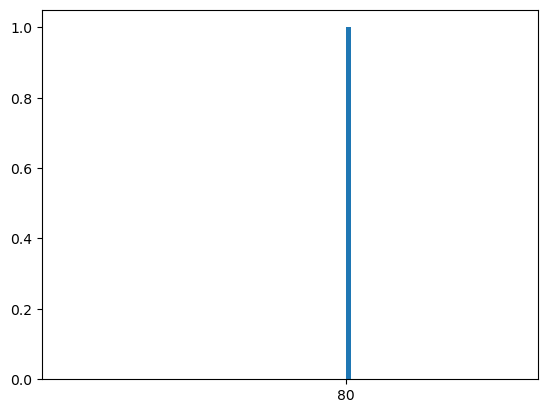

In [14]:
from matplotlib import pyplot as plt
import numpy as np
bins = np.arange(15, 120, 1) # fixed bin size

plt.hist(URError+LRError+ULError+LLError, bins=bins, alpha=1)
plt.xticks(URError+LRError+ULError+LLError)
plt.show()

# Error

- Not reading every text items. <= Last columns are dropped.

- Office Locations are violated.

**2.Miss Assignment Error**